In [1]:
# @title
!pip install --quiet colorcet SciencePlots score_models

In [55]:
#@title Utility functions, make sure to run this cell

%matplotlib inline
from typing import Callable

import numpy as np
import torch.distributions as tfd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.cm as cm
import scienceplots
import colorcet as cc
import pylab
import torch
from tqdm import tqdm
from scipy.interpolate import interpn
from scipy.special import logsumexp
from matplotlib.colors import Normalize

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.style.use('dark_background')
plt.style.use('science')
params = {
         'figure.figsize': (4, 4),
         'figure.titlesize': 24,
         'axes.labelsize': 18,
         'axes.titlesize': 24,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'legend.fontsize': 16,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'ytick.major.size': 8,
         'ytick.minor.size': 4,
         'text.usetex': True,
         'text.latex.preamble': r'\usepackage{bm, physics}',
         }
pylab.rcParams.update(params)
cmap = cc.cm.fire

def plot_density(
        logp_fn: Callable,
        fig=None, 
        ax=None, 
        extent=(-2, 2, -2, 2),
        dx=None, 
        dy=None,
        colorbar=False, 
        cmap=cmap, 
        vmin=None, 
        vmax=None, 
        **kwargs):
    """
    Plot the density of a log probability function
    """
    # Generate a grid of points
    (xmin, xmax, ymin, ymax) = extent
    if dx is None:
        dx = (xmax - xmin) / 100
    if dy is None:
        dy = (ymax - ymin) / 100
    x = np.arange(xmin, xmax, dx)
    y = np.arange(ymin, ymax, dy)
    n = x.size
    m = y.size
    points = np.stack(np.meshgrid(x, y, indexing="xy"), axis=-1).reshape((-1, 2))
    # Compute log probability and normalize to get the density
    logp = logp_fn(torch.tensor(points).to(DEVICE).float()).detach().cpu().numpy().reshape([m, n])
    p = np.exp(logp - logsumexp(logp + np.log(dx) + np.log(dy)))
    # Plot the density
    norm = Normalize(vmin=p.min() if vmin is None else vmin, vmax=p.max() if vmax is None else vmax)
    if ax is None:
        fig, ax = plt.subplots()
    im = ax.imshow(p, extent=extent, cmap=cmap, norm=norm, aspect="auto", origin="lower", **kwargs)
    if colorbar and fig is not None:
        cax = fig.colorbar(im, ax=ax, fraction=0.038, pad=0.02)
        cax.set_ylabel(r'$p(\mathbf{x})$')
    return ax

def plot_scatter(
        points, 
        fig=None, 
        ax=None, 
        bins=20, 
        sort=True, 
        norm=None, 
        ticks=None, 
        colorbar=False,
        extent=None,
        cmap=cmap, 
        **kwargs):
    """
    Scatter plot colored by 2d histogram
    """
    x = points[:, 0]
    y = points[:, 1]
    if extent is None:
        extent = ((x.min(), x.max()), (y.min(), y.max()))
    else:
        extent = ((extent[0], extent[1]), (extent[2], extent[3]))
    # Compute histogram and intepolate density
    data, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True, range=extent)
    x_bins = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_bins = 0.5 * (y_edges[1:] + y_edges[:-1])
    z = interpn((x_bins, y_bins), data, np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.where(np.isnan(z))] = 0.0
    # Sort the points by density, so that the densest points are plotted last
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    if ax is None:
        fig, ax = plt.subplots()
    if norm is None:
        norm = Normalize(vmin=z.min(), vmax=z.max())
    ax.scatter(x, y, c=z, cmap=cmap, norm=norm, **kwargs)
    if fig is not None and colorbar:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0*1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax, ticks=ticks)
        cax.set_ylabel(r'$p(\mathbf{x})$')
    ax.set_xlim(extent[0])
    ax.set_ylim(extent[1])
    return ax


def plot_score(
        score_fn: Callable,
        fig=None,
        ax=None,
        extent=(-2, 2, -2, 2),
        n=20, 
        scale=None, 
        width=0.007,
        colorbar=False,
        cmap=cmap,
        ):
    """
    Plot a vector field
    """
    # Generate a grid of points
    (xmin, xmax, ymin, ymax) = extent
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    points = np.stack(np.meshgrid(x, y), axis=-1).reshape((-1, 2))
    g = score_fn(torch.tensor(points).to(DEVICE).float()).detach().cpu().numpy().reshape([n, n, 2])
    colors = np.sqrt(g[..., 0]**2 + g[..., 1]**2).ravel()
    if ax is None:
        fig, ax = plt.subplots()
    norm = Normalize()
    ax.quiver(x, y, g[..., 0], g[..., 1], color=cmap(norm(colors)), scale=scale, width=width)
    if fig is not None and colorbar:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0*1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax)
        cax.set_ylabel(r"$\lVert \nabla \log p(\mathbf{x}) \rVert$")
    return ax

def plot_contours(
        logp_fn: Callable,
        fig=None,
        ax=None,
        extent=(-2, 2, -2, 2),
        ci: tuple = (0.68, 0.95, 0.99),
        dx=None, 
        dy=None,
        cmap=cc.cm.fire,
        ):
    """
    Plot density contours
    """
    # Generate a grid of points
    (xmin, xmax, ymin, ymax) = extent
    if dx is None:
        dx = (xmax - xmin) / 100
    if dy is None:
        dy = (ymax - ymin) / 100
    x = np.arange(xmin, xmax, dx)
    y = np.arange(ymin, ymax, dy)
    n = x.size
    m = y.size
    points = np.stack(np.meshgrid(x, y), axis=-1).reshape((-1, 2))
    # Compute log probability and normalize to get the density
    logp = logp_fn(torch.tensor(points).to(DEVICE)).detach().cpu().numpy().reshape([m, n])
    p = np.exp(logp - logsumexp(logp))
    # Compute the cumulative probability
    cumul = np.sort(p.ravel() * dx * dy)[::-1].cumsum()
    ps = []
    for _ci in ci:
        p_at_ci = np.sort(p.ravel())[::-1][np.argmin((cumul - _ci)**2)]
        ps.append(p_at_ci)
    colors = [cmap(i/(len(ci)-1)) for i in range(len(ci))]
    contours = ax.contour(x, y, p, levels=ps[::-1], colors=colors, linewidths=2, linestyles="--")
    if ax is None:
        fig, ax = plt.subplots()
    def fmt(x):
        ci = cumul[np.argmin((x - np.sort(p.ravel())[::-1])**2)]
        s = f"{ci*100:.1f}"
        if s.endswith("0"):
            s = f"{ci*100:.0f}"
        return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
    ax.clabel(contours, contours.levels, inline=True, fmt=fmt, fontsize=10)
    return ax

def two_moons(modes=128, width=0.1, size=1, device=DEVICE) -> tfd.Distribution:
    """
    Returns a 2 moons distributions from a mixture of <modes> gaussian distributions
    :param modes: Number of modes inside each moon
    :param width: Width of the moons
    :param size: scales the coordinates by this amount
    """
    outer_circ_x = torch.cos(torch.linspace(0, np.pi, modes)) - .5
    outer_circ_y = torch.sin(torch.linspace(0, np.pi, modes)) - .25
    inner_circ_x = - torch.cos(torch.linspace(0, np.pi, modes)) + .5
    inner_circ_y = - torch.sin(torch.linspace(0, np.pi, modes)) + .25
    x = torch.concat([outer_circ_x, inner_circ_x])
    y = torch.concat([outer_circ_y, inner_circ_y])
    coords = size * torch.stack([x, y], dim=1).to(device)
    mixture = tfd.Categorical(probs=torch.ones(2*modes).to(device), validate_args=False)  # Uniform
    component = tfd.Independent(tfd.Normal(loc=coords, scale=width, validate_args=False), 1)  # Diagonal Multivariate Normal
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

def eggbox(
        modes: int = 16, 
        mode_width: float = 0.5, 
        size: float = None, 
        weights: tuple[float] = None, 
        device=DEVICE) -> tfd.Distribution:
    """
    Returns gaussian mixture equally spaces on the 2d plane.

    Parameters:
        modes: Number of modes in the mixture
        size: Size egg box
        mode_width: Width of the modes
        weights: Weights of the modes
    """
    assert int(np.sqrt(modes))**2 == modes, f"modes = {modes} is not a square number"
    if size is None:
        size = modes**(1/2)
    x = torch.linspace(-1, 1, int(np.sqrt(modes))).to(device)
    x, y = torch.meshgrid(x, x, indexing="xy")
    coords = size * torch.stack([x.ravel(), y.ravel()], dim=1)
    if weights is None:
        weights = torch.ones(modes).to(device)
        weights /= weights.sum()
    else:
        weights = torch.tensor(weights).to(device)
        weights /= weights.sum()
    mixture = tfd.Categorical(probs=weights, validate_args=False)
    component = tfd.Independent(tfd.Normal(loc=coords, scale=mode_width, validate_args=False), 1)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)

def swiss_roll(modes=128, size=0.1, width=0.1, spread=0.7, device=DEVICE) -> tfd.Distribution:
    """
    Returns a swiss roll distribution from of a mixture of <modes> gaussian distributions
        :param modes: Number of modes in the mixture
        :param size: Size of the swiss roll
        :param width: Width of the modes in the swiss roll
        :param spread: Angular spread of the modes in the swiss roll
    """
    assert (spread > 0)
    t = 1.5 * np.pi * (1 + 2 * torch.linspace(0, 1, modes)**(spread))
    x = t * torch.cos(t)
    y = t * torch.sin(t)
    coords = size * torch.stack([x, y], dim=1).to(device)
    mixture = tfd.Categorical(probs=torch.ones(modes).to(device), validate_args=False)
    component = tfd.Independent(tfd.Normal(loc=coords, scale=width, validate_args=False), 1)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)


def five_swiss_rolls(modes=128, size=0.1, width=0.1, spread=0.7, offset=3, device=DEVICE):
    """
    Returns 5 swiss roll distribution arranged in the classic 5 dots pattern
        :param modes: Number of modes in the mixture
        :param size: Size of the swiss roll
        :param width: Width of the modes in the swiss roll
        :param spread: Angular spread of the modes in the swiss roll
        :param offset: Distance between the swiss rolls
    """
    assert (spread > 0)
    offsets = [[-offset, offset], [offset, -offset], [offset, offset], [-offset, -offset]]
    coords = []
    for k in range(5):
        t = 1.5 * np.pi * (1 + 2 * torch.linspace(0, 1, modes)**(spread))
        x = size * t * torch.cos(t)
        y = size * t * torch.sin(t)
        if k > 0:
            x += offsets[k-1][0]
            y += offsets[k-1][1]
        coords.append(torch.stack([x, y], dim=1))
    coords = torch.concat(coords, dim=0).to(device)
    mixture = tfd.Categorical(probs=torch.ones(5*modes).to(device), validate_args=False)
    component = tfd.Independent(tfd.Normal(loc=coords, scale=width, validate_args=False), 1)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)


def two_modes(mode_width=0.3):
    """
    Returns a distribution with two modes
    """
    mixture = tfd.Categorical(probs=torch.tensor([0.5, 0.5]).to(DEVICE), validate_args=False)
    component = tfd.Independent(tfd.Normal(loc=torch.tensor([[-1.0, 1.0]]).T.to(DEVICE), scale=mode_width, validate_args=False), 1)
    return tfd.MixtureSameFamily(mixture, component, validate_args=False)


# Motivations for Score-Based Models (SBM)



## Sampling in high-dimensions

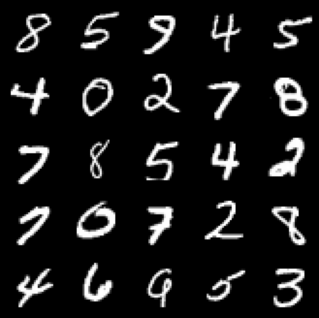

In [3]:
from torchvision.datasets import MNIST
import torchvision.transforms as T

data = MNIST(root=".", download=True, transform=T.ToTensor())

fig, axs = plt.subplots(5, 5, figsize=(4, 4))
for i, ax in enumerate(axs.flatten()):
    k = np.random.randint(0, len(data))
    ax.imshow(data[k][0].squeeze(), cmap="gray")
    ax.axis("off")

## High-dimensional Bayesian inference
Given (corrupted) observation $y$, sample from the posterior over the parameters of interest $x \in \mathcal{X} \subseteq  \mathbb{R}^n$ when $n \gg 1$
$$
    p(x \mid y) = \frac{p(y \mid x) p(x)}{\int_{\mathcal{X}} p(y \mid x) p(x) \mathrm{d} x}
$$

Simplest example is denoising, where the data generating process is given by
$$
    y = x + \eta
$$
for $\eta \sim \mathcal{N}(0, \sigma^2)$. 

In [4]:
sevens = [data[i][0].squeeze() for i in range(1000) if data[i][1] == 7]

In [5]:
# Ground truth
x_true = sevens[0]

# Observation
sigma = 0.3
y = x_true + sigma * torch.randn_like(x_true)

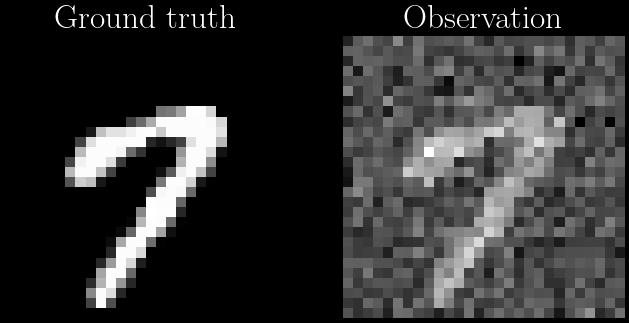

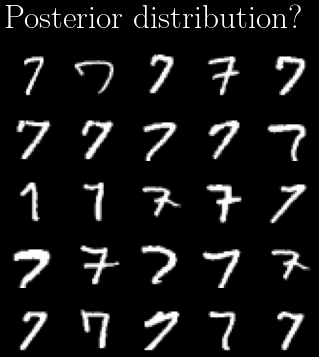

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(x_true, cmap="gray")
ax1.set_title("Ground truth")
ax1.axis("off")
ax2.imshow(y, cmap="gray")
ax2.set_title("Observation")
ax2.axis("off")

fig, axs = plt.subplots(5, 5, figsize=(4, 4))
fig.suptitle("Posterior distribution?")
for i, ax in enumerate(axs.flatten()):
    k = np.random.randint(0, len(sevens))
    ax.imshow(sevens[k].numpy(), cmap="gray")
    ax.axis("off")

## Density estimation in high dimension?

- We would like to describe our prior $p(x)$, but there is no simple formula to describe distribution of images (e.g. MNIST, galaxies, etc).


- A probability distribution must be normalized over the domain $\mathcal{X} \subseteq \mathbb{R}^n$
$$
    \int_{\mathcal{X}} p(x) \mathrm{d} x = 1\, .
$$

# What is the score?

(Stein's) score function is the gradient of the log probability
$$
  s(x) \equiv \nabla_{x}\log p(x)
$$

In [7]:
from torch.func import vmap, grad

# Distributions
d = two_moons()
# d = eggbox(4, size=1, mode_width=0.1)
# d = swiss_roll()
# d = five_swiss_rolls()

def logp(x, d=d):
    return d.log_prob(x)

def score(x, d=d):
    return vmap(grad(d.log_prob))(x)

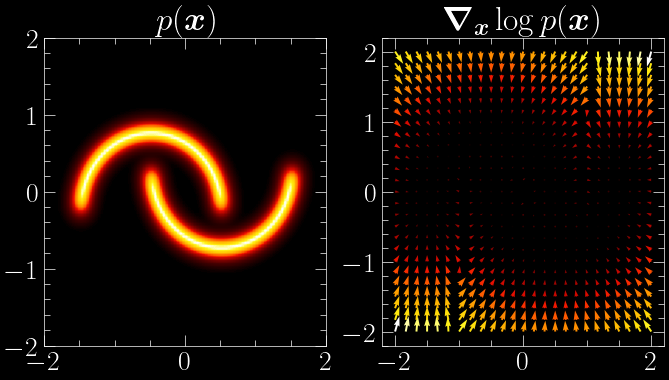

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
# extent = (-1.5, 1.5, -1.5, 1.5) # Swiss roll
extent = (-2, 2, -2, 2) # two moons / eggbox
# extent = (-5, 5, -5, 5) # five swiss rolls

plot_density(logp, fig=fig, ax=ax1, extent=extent)
ax1.set_title(r"$p(\bm{x})$")
plot_score(score, fig=fig, ax=ax2, extent=extent, n=25)
ax2.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$");

## The score is local (for a Gibbs measure)

If $p(x)$ can be written in terms of the Gibbs measure
$$
    p(x) = \frac{1}{\mathcal{Z}}e^{- E(x)}\, ,
$$
where
$$
    \mathcal{Z} = \int_{\mathcal{X}} e^{-E(x)}\, ,
$$
then the score function is purely local, independent of $\mathcal{Z}$
$$
    \boxed{\nabla_{x} \log p(\mathbf{x}) = -\nabla_{x} E(x)}
$$

In [9]:
d = eggbox(modes=4, mode_width=0.1, size=1)
weighted_d = eggbox(modes=4, mode_width=0.1, size=1, weights=[1, 0.5, 0.5, 0.1])

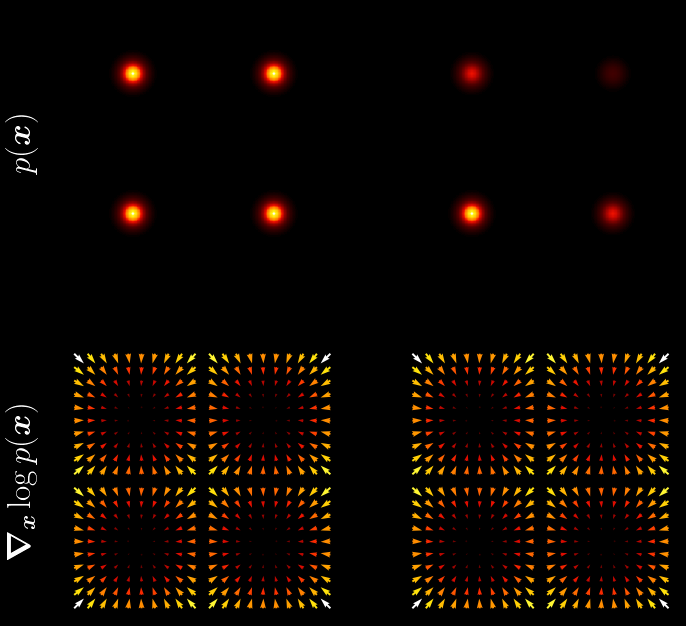

In [10]:
from functools import partial
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

ax = axs[0, 0]
plot_density(partial(logp, d=d), fig=fig, ax=ax)
ax.annotate(r"$p(\bm{x})$", xy=(-0.2, 0.5), xycoords="axes fraction", fontsize=24, color="white", rotation=90, va="center")
ax.axis("off")

ax = axs[0, 1]
plot_density(partial(logp, d=weighted_d), fig=fig, ax=ax)
ax.axis("off")

ax = axs[1, 0]
plot_score(partial(score, d=d), fig=fig, ax=ax)
ax.annotate(r"$\grad_{\bm{x}} \log p(\bm{x})$", xy=(-0.2, 0.5), xycoords="axes fraction", fontsize=24, color="white", rotation=90, va="center")
ax.axis("off")

ax = axs[1, 1]
plot_score(partial(score, d=weighted_d), fig=fig, ax=ax)
ax.axis("off");


## The normalization can be recovered through annealing

In [11]:
mode_width = 0.9 # Increase the width of the modes
weighted_d = eggbox(modes=4, mode_width=mode_width, size=1, weights=[1, 0.5, 0.5, 0.1])

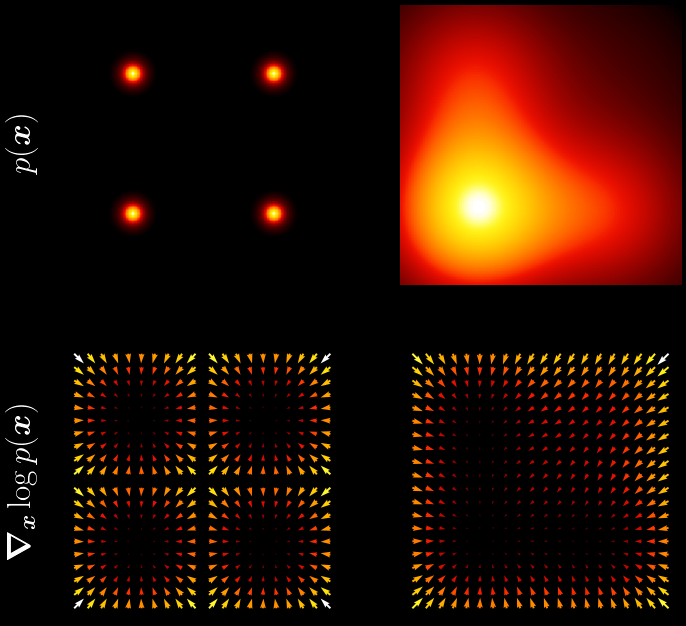

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

ax = axs[0, 0]
plot_density(partial(logp, d=d), fig=fig, ax=ax)
ax.annotate(r"$p(\bm{x})$", xy=(-0.2, 0.5), xycoords="axes fraction", fontsize=24, color="white", rotation=90, va="center")
ax.axis("off")

ax = axs[0, 1]
plot_density(partial(logp, d=weighted_d), fig=fig, ax=ax)
ax.axis("off")

ax = axs[1, 0]
plot_score(partial(score, d=d), fig=fig, ax=ax)
ax.annotate(r"$\grad_{\bm{x}} \log p(\bm{x})$", xy=(-0.2, 0.5), xycoords="axes fraction", fontsize=24, color="white", rotation=90, va="center")
ax.axis("off")

ax = axs[1, 1]
plot_score(partial(score, d=weighted_d), fig=fig, ax=ax)
ax.axis("off");


# Naive Score Matching
Define a neural network $s_\theta: \mathbb{R}^n \rightarrow \mathbb{R}^n$
$$
    \mathcal{L}_\theta = \mathbb{E}_{p(x)} \bigg[ \big\lVert s_\theta(x) - \nabla_x \log p(x) \big\rVert_2^2 \bigg]
$$

The ideas of score matching were first developed by
- [Aapo Hyvarïnen (2005)](https://www.jmlr.org/papers/volume6/hyvarinen05a/hyvarinen05a.pdf)
- [Pascal Vincent (2011)](https://www.iro.umontreal.ca/~vincentp/Publications/DenoisingScoreMatching_NeuralComp2011.pdf)

A useful resource is [Yang Song's blog post](https://yang-song.net/blog/2021/score/)


In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, n=2, width=128, depth=2):
        super(Net, self).__init__()
        self.input_layer = nn.Linear(n, width)
        layers = []
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
        self.layers = nn.ModuleList(layers)
        self.output_layer = nn.Linear(width, n)
    
    def forward(self, x):
        x = F.silu(self.input_layer(x))
        for layer in self.layers:
            x = F.silu(layer(x))
        x = self.output_layer(x)
        return x

In [14]:
def naive_sm_loss(batch_size, model, distribution):
    x = distribution.sample((batch_size,))          # x ~ p(x)
    s_true = vmap(grad(distribution.log_prob))(x)   # s_true = ∇ log p(x)
    s_theta = model(x)
    return ((s_theta - s_true)**2).sum() / batch_size

In [15]:
B = int(2**8) # Batch size
N = 1000 # Number of iterations
d = eggbox(modes=4, mode_width=0.1, size=1) # Distribution to learn

net = Net()
optim = torch.optim.Adam(net.parameters(), lr=1e-3)
losses = []
for _ in tqdm(range(N)):
    loss = naive_sm_loss(B, net, d)
    optim.zero_grad()
    loss.backward()
    optim.step()
    losses.append(loss.item())

100%|██████████| 1000/1000 [00:03<00:00, 332.68it/s]


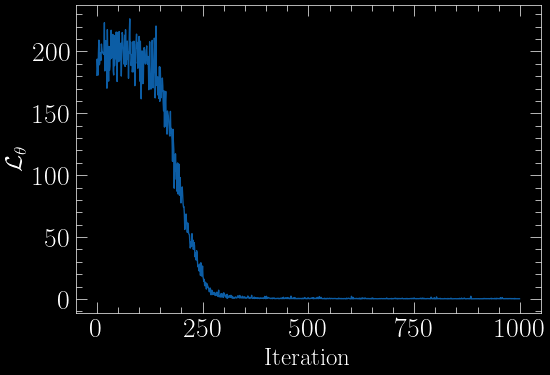

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{L}_\theta$");

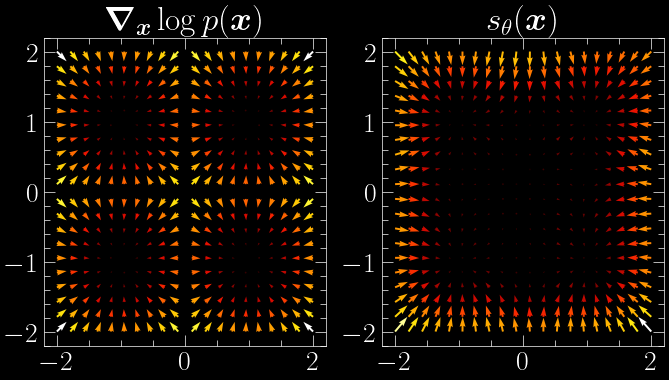

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

plot_score(partial(score, d=d), fig=fig, ax=ax1)
ax1.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$")

plot_score(net, fig=fig, ax=ax2)
ax2.set_title(r"$s_\theta(\bm{x})$");

# Why is the score useful?

We can sample from $p(x)$ by using
$$
  x_{t+1} = x_t + \nabla_{x_t}\log p(x_t) \Delta t + \sqrt{2 \Delta t}z
$$
where $\mathbf{z} \sim \mathcal{N}(0, 1)$ is a Brownina motion term.

## Brownian motion


In [48]:
N = 1000
dt = 1/N

# Wiener process
w = torch.zeros(1) # W_0 = 0
t = 0
states = [(t, w)]
for n in range(N):
    dw = torch.randn_like(w) * dt**0.5 # dW_n ~ N(0, dt)
    w = w + dw
    t = t + dt
    states.append((t, w))

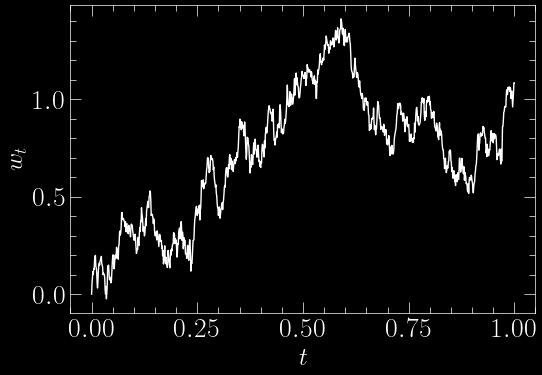

In [49]:
plt.figure(figsize=(6, 4))

plt.plot(*zip(*states), color="w")
plt.ylabel(r"$w_t$")
plt.xlabel(r"$t$");

## Langevin dynamics

In [50]:
d = two_modes(mode_width=0.1) # 1D distribution

N = 1000
dt = 1/N

# Wiener process
x = torch.zeros(1, 1)
t = 0
states = [(t, x.squeeze())]
for n in range(N):
    dw = torch.randn_like(x) * (2*dt)**0.5 # dW_n ~ N(0, dt)
    drift = score(x, d=d)
    x = x + drift * dt + dw
    t = t + dt
    states.append((t, x.squeeze()))

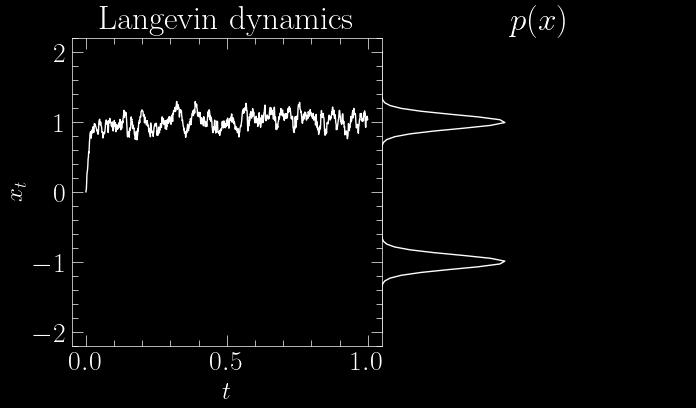

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ax1.plot(*zip(*states), color="w")
ax1.set_ylabel(r"$x_t$")
ax1.set_xlabel(r"$t$");
ax1.set_title(r"Langevin dynamics")

# plot density of distribution on the right (rotated so the density appears on the y axis)
x = torch.linspace(-2, 2, 100)
ax2.plot(d.log_prob(x.reshape(-1, 1)).exp(), x, color="w")
ax2.axis("off")
ax2.set_xlim(0, 5)
ax2.set_title(r"$p(x)$");

plt.subplots_adjust(wspace=0.0, hspace=0.0)

# Annealing

## Temperature (Gibbs measure)
To solve both the problem of sampling multimodal distribution and score matching, we want to add a temperature
$$
    p_\beta(x) = \frac{1}{\mathcal{Z}_\beta} \sum_i e^{-\beta E_i(x)}
$$

## Adding noise as a form of annealing
Adding noise $z \sim \mathcal{N}(z \mid )$ can be written as
$$
    x_t = x_0 + \sigma(t) z
$$
We have
$$
    p(x_t \mid x_0) = \mathcal{N}(x_t \mid x_0, \sigma^2(t))
$$

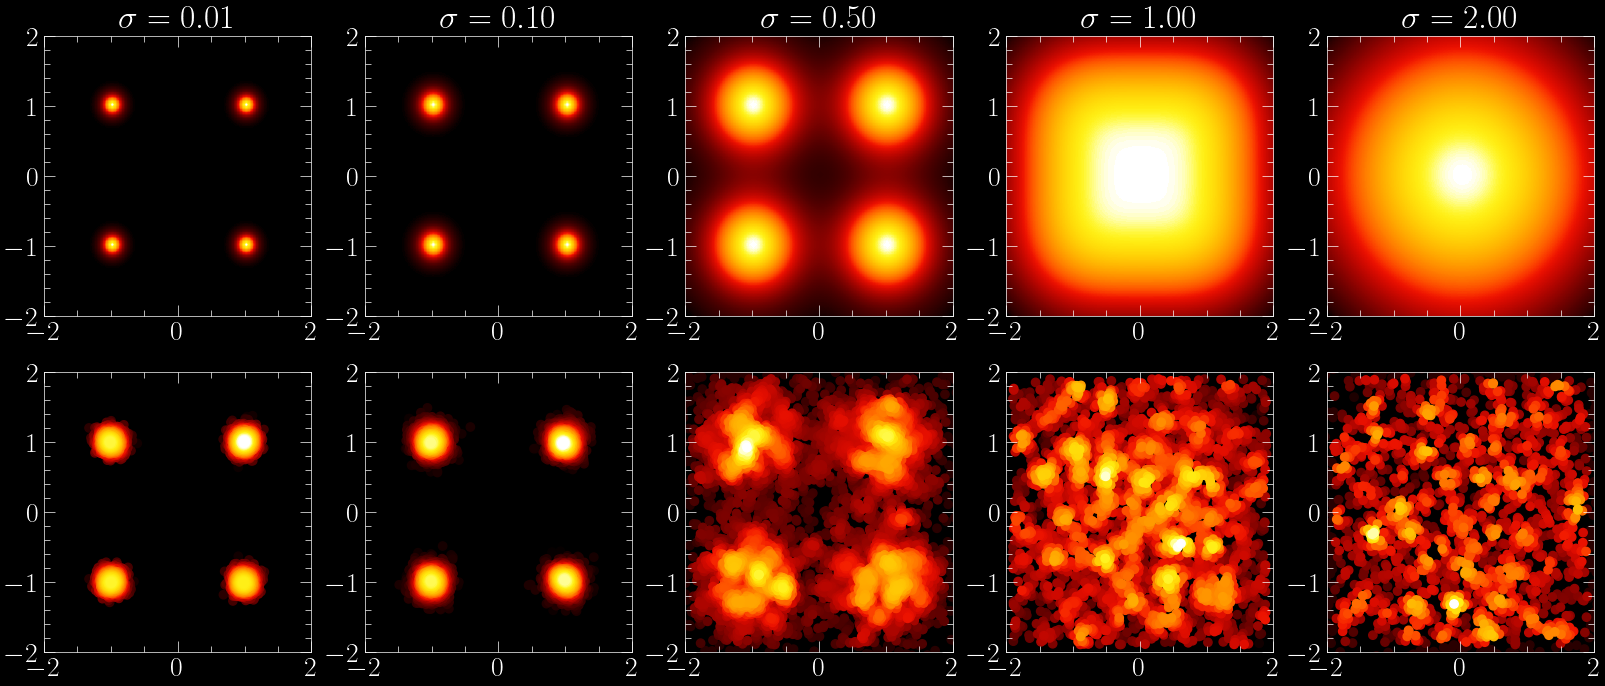

In [56]:
sigmas = [0.01, 0.1, 0.5, 1.0, 2.0]
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
extent = (-2, 2, -2, 2)

dist = partial(eggbox, size=1, modes=4)
d_true = dist(mode_width=0.1)
for sigma, ax in zip(sigmas, axs.T):
    d = dist(mode_width=(0.1**2 + sigma**2)**(1/2))
    plot_density(d.log_prob, fig=fig, ax=ax[0], extent=extent)
    ax[0].set_title(r"$\sigma = %.2f$" % sigma)

    x0 = d_true.sample((int(2**12),))
    z = torch.randn_like(x0)
    xt = x0 + sigma * z
    plot_scatter(xt.cpu().numpy(), bins=20, fig=fig, ax=ax[1], extent=extent)
    

# Denoising Score Matching

We can achieve annealing by adding noise to samples of our distribution ($x_0$)
$$
    x_t = x_0 + \sigma(t) z
$$
This corresponds to a perturbation kernel
$$
    p(x_t \mid x_0) = \mathcal{N}(x_t \mid x_0, \sigma^2(t))
$$
which we can use to train a neural network with the denoising score matching loss
$$
    \mathcal{L}_\theta = \int_0^t \mathbb{E}_{p(x_0, x_t)} \bigg[ \lambda(t) \big\lVert s_\theta(t, x_t) - \nabla_{x_t} \log p(x_t \mid x_0) \big\rVert_2^2\bigg]
$$

This is completely equivalent to score matching, and easy to do. We call it denoising because the loss function is equivalent to
$$
     \mathcal{L}_\theta = \int_0^t \mathbb{E}_{p(x_0, x_t)} \bigg[ \lambda(t) \big\lVert D_\theta(t, x_t) - x_0 \big\rVert_2^2\bigg]
$$

In [28]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, distribution, size=int(2**12)):
        self.data = distribution.sample((size,))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [40]:
from score_models import MLP, ScoreModel, VESDE

sigma_min = 1e-2
sigma_max = 5

sde = VESDE(sigma_min=sigma_min, sigma_max=sigma_max)
net = MLP(2)
model = ScoreModel(net, sde)

d = swiss_roll()
dataset = Dataset(d)

B = int(2**8) # Batch size
epochs = 100
losses = model.fit(dataset, batch_size=B, epochs=500, learning_rate=1e-3)


No path provided. Training checkpoints will not be saved.


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch 500 | Cost: 6.0e-01 |: 100%|██████████| 500/500 [00:52<00:00,  9.51it/s]

Finished training after 0.015 hours.


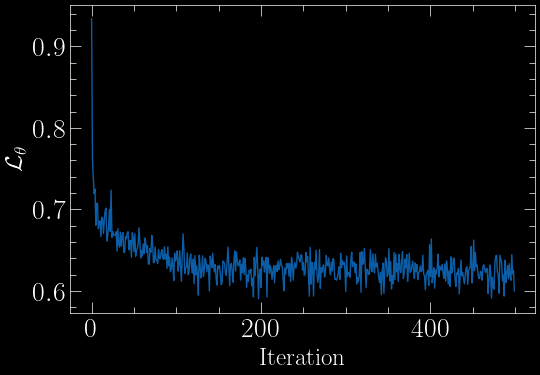

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{L}_\theta$");

### Empirical distribution

We can compare our model against the annealed empirical distribution

$$
    p(\mathbf{x}_t) = \sum_{i=1}^N \mathcal{N}(\mathbf{x}_t \mid \mathbf{x}_0^{(i)}, \sigma^2(t))\, ,
$$
where $\mathbf{x}_0^{(i)} \in \mathcal{D}$. 

In [42]:
def annealed_empirical_distribution_logp(t, x, dataset=dataset):
    # Technically, this is proportional to logp. I didn't bother to write the normalization constant
    energy = ((x.view(1, -1) - dataset.data)**2).sum(1) / (2 * model.sde.sigma(t)**2)
    return torch.logsumexp(-energy, 0)
    
def annealed_empirical_distribution_score(t, x):
    return vmap(grad(annealed_empirical_distribution_logp, argnums=1))(t, x)

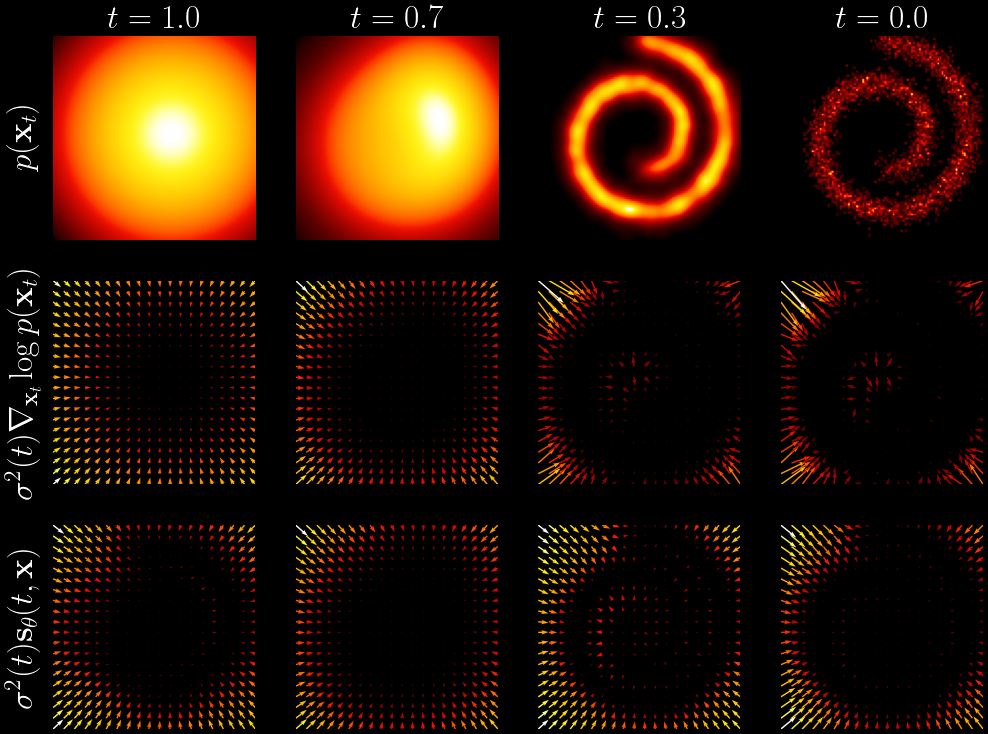

In [43]:
fig, axs = plt.subplots(3, 4, figsize=(12, 9), sharex=True, sharey=True)
extent = (-1.5, 1.5, -1.5, 1.5)

for i in range(4):
    t = float(np.linspace(0, 1, 4)[::-1][i])
    ax = axs[0, i]
    logp_fn = lambda x: vmap(annealed_empirical_distribution_logp)(torch.tensor([t]).repeat(x.shape[0]), x)
    plot_density(logp_fn, ax=ax, extent=extent)
    ax.set_title(r"$t = %.1f$" % t)
    ax.axis("off")

    ax = axs[1, i]
    score_fn = lambda x: annealed_empirical_distribution_score(torch.tensor([t]).repeat(x.shape[0]), x) * model.sde.sigma(t)**2
    plot_score(score_fn, ax=ax, extent=extent, scale=None)
    ax.axis("off")

    ax = axs[2, i]
    score_fn = lambda x: model(torch.tensor([t]).repeat(x.shape[0]), x) * model.sde.sigma(t)
    plot_score(score_fn, ax=ax, extent=extent, scale=None)
    ax.axis("off");
axs[0, 0].annotate(r"$p(\mathbf{x}_t)$", (-0.15, 0.5), 
    xycoords="axes fraction", va="center", ha="center", rotation=90, fontsize=24)
axs[1, 0].annotate(r"$\sigma^2(t)\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)$", (-0.15, 0.5), 
    xycoords="axes fraction", va="center", ha="center", rotation=90, fontsize=24)
axs[2, 0].annotate(r"$\sigma^2(t)\mathbf{s}_\theta(t, \mathbf{x})$", (-0.15, 0.5),
    xycoords="axes fraction", va="center", ha="center", rotation=90, fontsize=24);

# Sampling with the SDE

In [44]:
B = int(2**12)
x0 = model.sample(shape=(B, 2), steps=100)

t=0.01 | sigma=0.01 | x=0.1±0.7: 100%|██████████| 100/100 [00:02<00:00, 39.54it/s]


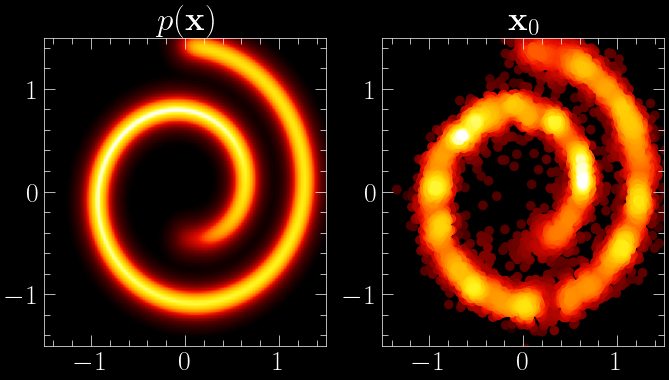

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
extent = (-1.5, 1.5, -1.5, 1.5)

plot_density(partial(logp, d=d), ax=ax1, extent=extent)
ax1.set_title(r"$p(\mathbf{x})$")

plot_scatter(x0, ax=ax2, bins=20, extent=extent)
ax2.set_title(r"$\mathbf{x}_0$");